<a href="https://colab.research.google.com/github/wajdalkhaldi/NLP/blob/main/lab4/Lab4_Classification_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

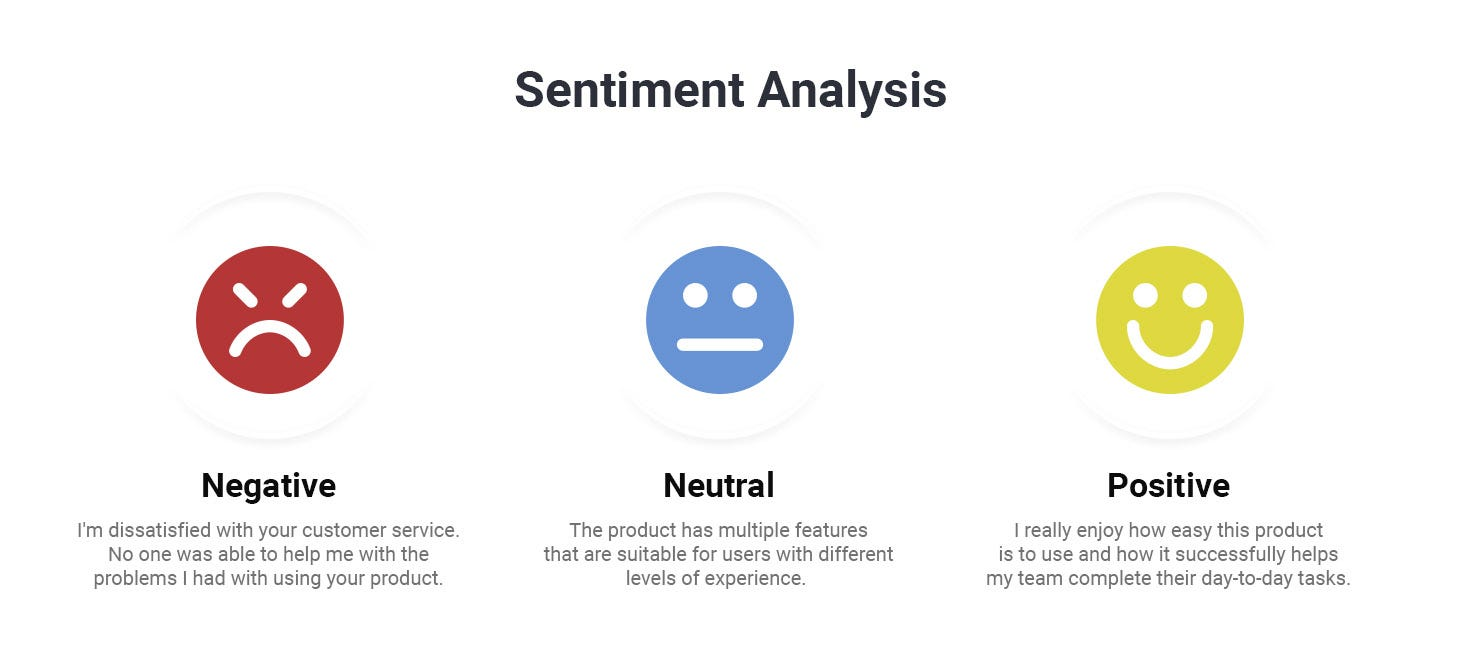

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [2]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1') #encoding type so it can read special char and symbols
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [3]:
#Check for missing values
data.isna().sum()

,0
Review_ID,0
Rating,0
Year_Month,0
Reviewer_Location,0
Review_Text,0
Branch,0


In [4]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [5]:
# Map star ratings to sentiments
#lambda rule
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [6]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [7]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer #for feature extraction which transfer the data to numerical data

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42) #random state for reproducability


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens (max features indicate to focus on 1000 most important features)
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [8]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [10]:
from sklearn.svm import SVC #for svm
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

In [16]:
#Task1: Load the data and do 5 different preprocessing steps on it
import pandas as pd
import re
import nltk
import csv

# Load the dataset
data = pd.read_csv(
    '/content/Amazon_Unlocked_Mobile.csv',
    engine='python',
    on_bad_lines='skip'
)

# Display the first rows
data.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [27]:
#5 preprocessing steps: 1-Lowercase 2-Remove punctuation/special characters 3-Remove numbers 4-Remove extra whitespace 5-Remove stopwords
# Download stopwords
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Create sentiment from ratings
def get_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating <= 2:
        return 'negative'
    else:
        return 'neutral'

data['Sentiment'] = data['Rating'].apply(get_sentiment)


# Text preprocessing function
def preprocess_text(text):

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 3. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 4. Tokenize
    words = text.split()

    # 5. Apply stemming
    from nltk.stem import PorterStemmer
    stemmer = PorterStemmer()
    words = [stemmer.stem(word) for word in words]

    return ' '.join(words)


# Remove missing reviews
data = data.dropna(subset=['Reviews', 'Rating'])

# Apply preprocessing
data['Cleaned_Reviews'] = data['Reviews'].apply(preprocess_text)

# Display the result
data[['Reviews', 'Cleaned_Reviews', 'Rating', 'Sentiment']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Reviews,Cleaned_Reviews,Rating,Sentiment
0,I feel so LUCKY to have found this used (phone...,i feel so lucki to have found thi use phone to...,5,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice up grade from my pantach revu ...,4,positive
2,Very pleased,veri pleas,5,positive
3,It works good but it goes slow sometimes but i...,it work good but it goe slow sometim but it a ...,4,positive
4,Great phone to replace my lost phone. The only...,great phone to replac my lost phone the onli t...,4,positive


In [18]:
#Task2: Use a proper train and test split
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X = data['Cleaned_Reviews']
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (85960,)
Testing set size: (21490,)


In [19]:
#Task3: Do Feature Extraction Using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

# Fit TF-IDF only on training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (85960, 5000)
Testing TF-IDF shape: (21490, 5000)


In [20]:
#Task4: Train a Naive Bayes Classifier
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB()

# Train the classifier
nb_classifier.fit(X_train_tfidf, y_train)

print("Naive Bayes classifier trained successfully.")

Naive Bayes classifier trained successfully.


In [21]:
# Task 5: Evaluate the model

from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred = nb_classifier.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.81      0.83      5143
     neutral       0.55      0.07      0.12      1243
    positive       0.90      0.97      0.93     15104

    accuracy                           0.88     21490
   macro avg       0.76      0.62      0.63     21490
weighted avg       0.86      0.88      0.86     21490



In [22]:
# Task 6: printing Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['negative', 'neutral', 'positive']
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 4173    13   957]
 [  409    87   747]
 [  388    57 14659]]


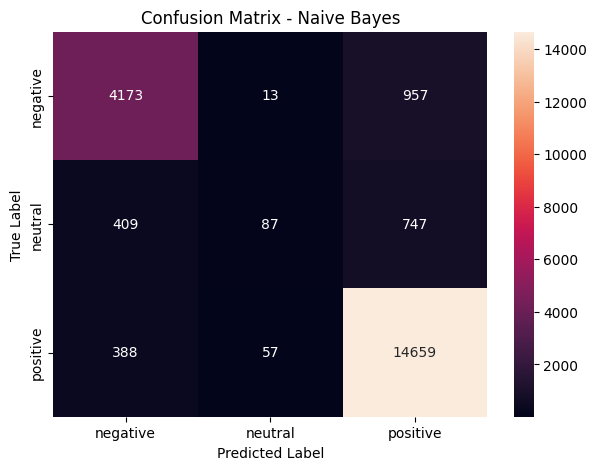

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['negative', 'neutral', 'positive']

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()